# The resource-consumer NP model with odeint - SLXVIC001

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

The code below represents the dynamics
$$\frac{dN}{dt}=-k NP$$
$$\frac{dP}{dt}=k NP$$
The parameter $k$ is an input to the function

In [3]:
# function that returns the right hand side of the above equations
def model(state,t,k):
    N,P = state
    Ndot = -k * N * P
    Pdot =  k * N * P
    return np.array([Ndot,Pdot])

Set the initial conditions, the time axis and solve the ODE

In [4]:
# initial conditions
K = 0.1
N0 = 5.
P0 = 0.1
state0 = np.array([N0,P0])

# time points (days)
t = np.linspace(0,20,num=100)

# solve ODE using odeint (remember that args is a tuple)
y = odeint(model,state0,t,args=(K,))

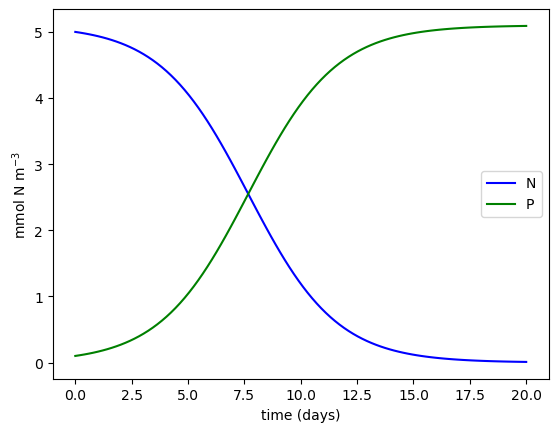

In [5]:
# plot the resulting time series
plt.plot(t,y[:,0],'b',label='N')
plt.plot(t,y[:,1],'g',label='P')
plt.xlabel('time (days)')
plt.ylabel('mmol N m$^{-3}$')
plt.legend()
plt.show()

# Exercise 7
#### 1. What are the inputs and outputs in the function model? What kind of objects are they?
The inputs are the initial conditions, which consist of k (growth or consumption rate), N0 (the initial nutrient concentration) and P0 (the initial phytoplankton biomass). 

K is a constant, a parameter. 
N and P are arrays of values. 

The outputs are the values after interacting for a set period of time. The resulting concentrations of and P. After experiencing K over time. The outputs are also arrays. 

#### 2. Write a new model to simulate the nutrient-phytoplankton-detritus system (NPD). Include a detritus variable D that is produced from the mortality of phytoplankton and it is remineralized as a nutrient. This will involve adding 2 new parameters: the mortality rate (phytoplankton lysis) and the remineralization rate.

The model equations can be written using latex. Check the code in the inital cell above. Otherwise you can use the equation editor on Word or LibreOffice.

This model produced 2 new plots showing the effect of both new and added parameters.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

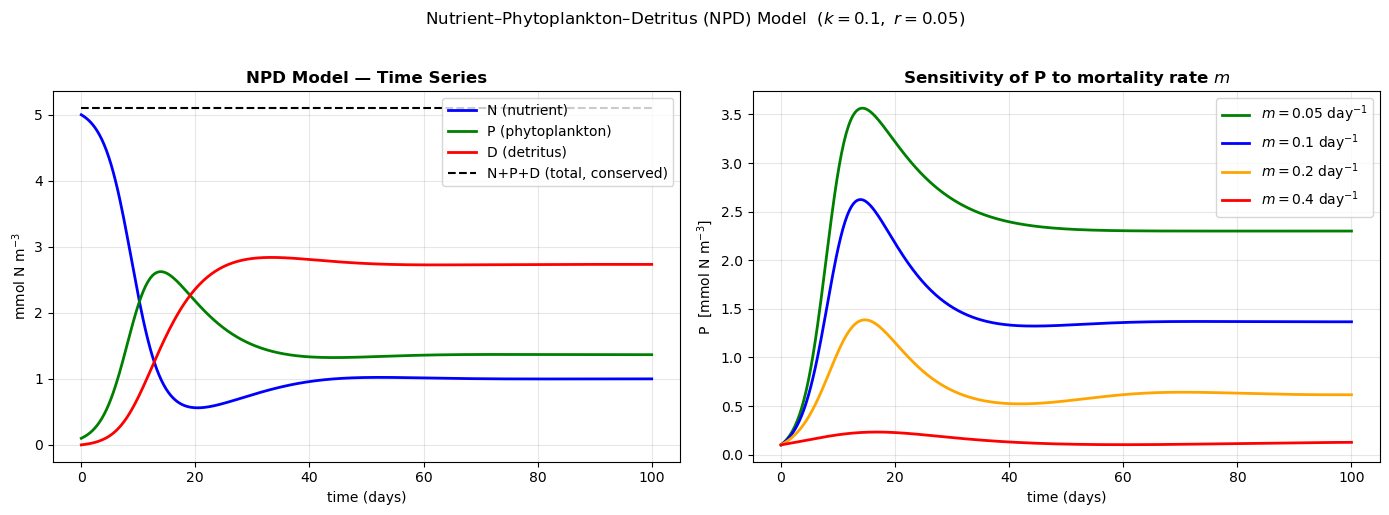


Conservation check — initial total: 5.100, final total: 5.100  (should be equal)


In [7]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from IPython.display import display, Math

# ── Model equations (LaTeX display) ─────────────────────────────────────────
display(Math(r'\textbf{NPD Model Equations:}'))
display(Math(r'\frac{dN}{dt} = -k\,N\,P + r\,D'))
display(Math(r'\frac{dP}{dt} = k\,N\,P - m\,P'))
display(Math(r'\frac{dD}{dt} = m\,P - r\,D'))
display(Math(r'\text{where: } k = \text{uptake rate,}\ '
             r'm = \text{mortality rate,}\ '
             r'r = \text{remineralisation rate}'))

# ── NPD model ────────────────────────────────────────────────────────────────
def model_NPD(state, t, k, m, r):
    """
    N : nutrient        [mmol N m^-3]
    P : phytoplankton   [mmol N m^-3]
    D : detritus        [mmol N m^-3]

    k : uptake/growth rate       [m^3 mmol^-1 day^-1]
    m : phytoplankton mortality  [day^-1]
    r : detritus remineralisation[day^-1]
    """
    N, P, D = state
    Ndot = -k * N * P + r * D   # nutrient: lost to growth, gained from remineralisation
    Pdot =  k * N * P - m * P   # phyto:    gained from growth, lost to mortality
    Ddot =  m * P       - r * D # detritus: gained from mortality, lost to remineralisation
    return np.array([Ndot, Pdot, Ddot])

# ── Parameters ───────────────────────────────────────────────────────────────
K  = 0.1    # uptake rate        [m^3 mmol^-1 day^-1]
M  = 0.1    # mortality rate     [day^-1]
R  = 0.05   # remineralisation   [day^-1]

N0 = 5.0
P0 = 0.1
D0 = 0.0
state0 = np.array([N0, P0, D0])

t = np.linspace(0, 100, num=500)

# ── Solve ────────────────────────────────────────────────────────────────────
y = odeint(model_NPD, state0, t, args=(K, M, R))

# ── Plot 1: Time series ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(t, y[:, 0], 'b',  lw=2, label='N (nutrient)')
ax.plot(t, y[:, 1], 'g',  lw=2, label='P (phytoplankton)')
ax.plot(t, y[:, 2], 'r',  lw=2, label='D (detritus)')
ax.plot(t, y.sum(axis=1), 'k--', lw=1.5, label='N+P+D (total, conserved)')
ax.set_xlabel('time (days)')
ax.set_ylabel(r'mmol N m$^{-3}$')
ax.set_title('NPD Model — Time Series', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Plot 2: Sensitivity to mortality rate ────────────────────────────────────
ax = axes[1]
m_values = [0.05, 0.1, 0.2, 0.4]
colors   = ['green', 'blue', 'orange', 'red']

for m_val, color in zip(m_values, colors):
    y_sens = odeint(model_NPD, state0, t, args=(K, m_val, R))
    ax.plot(t, y_sens[:, 1], color=color, lw=2,
            label=r'$m = $' + f'{m_val}' + r' day$^{-1}$')

ax.set_xlabel('time (days)')
ax.set_ylabel(r'P  [mmol N m$^{-3}$]')
ax.set_title(r'Sensitivity of P to mortality rate $m$', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(r'Nutrient–Phytoplankton–Detritus (NPD) Model  '
             r'($k=0.1,\ r=0.05$)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('NPD_model.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nConservation check — initial total: {N0+P0+D0:.3f}, "
      f"final total: {y[-1].sum():.3f}  (should be equal)")

#### 3. Write the code to solve the new model using odeint and propose some reasonable values for the parameters that lead to a realistic solution

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

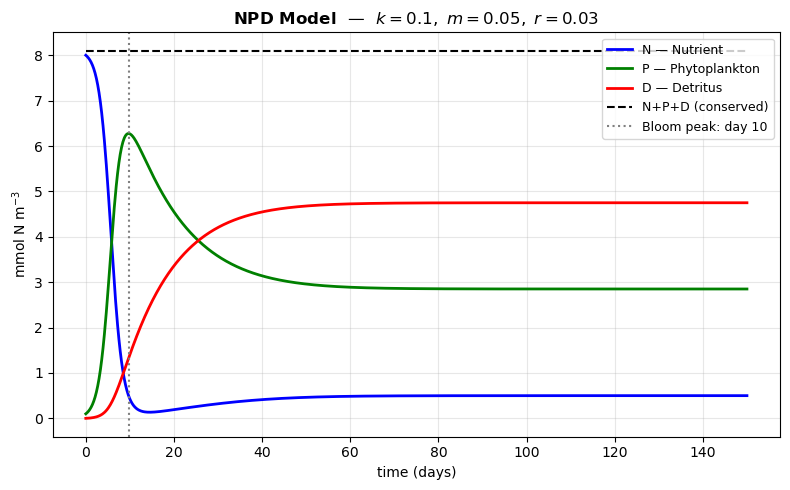

Bloom peak (P_max):   6.28 mmol N m⁻³  at day 9.8
Steady-state N:       0.50 mmol N m⁻³
Steady-state P:       2.85 mmol N m⁻³
Steady-state D:       4.75 mmol N m⁻³
Conservation check:   initial = 8.10,  final = 8.10


In [10]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from IPython.display import display, Math

# ── Parameter justification ──────────────────────────────────────────────────
display(Math(r'\textbf{Parameter choices (realistic marine values):}'))
display(Math(r'k = 0.1 \ \mathrm{m^3\ mmol^{-1}\ day^{-1}} \quad '
             r'\text{(phytoplankton uptake rate — typical temperate ocean)}'))
display(Math(r'm = 0.05 \ \mathrm{day^{-1}} \quad '
             r'\text{(phytoplankton mortality/lysis — approx. 2\% per day)}'))
display(Math(r'r = 0.03 \ \mathrm{day^{-1}} \quad '
             r'\text{(remineralisation — slower than mortality, bacterial decomposition)}'))
display(Math(r'N_0 = 8.0,\quad P_0 = 0.1,\quad D_0 = 0.0 \quad '
             r'[\mathrm{mmol\ N\ m^{-3}}] \quad '
             r'\text{(pre-bloom spring conditions)}'))

# ── NPD model ────────────────────────────────────────────────────────────────
def model_NPD(state, t, k, m, r):
    N, P, D = state
    Ndot = -k * N * P + r * D
    Pdot =  k * N * P - m * P
    Ddot =  m * P     - r * D
    return np.array([Ndot, Pdot, Ddot])

# ── Realistic parameters ─────────────────────────────────────────────────────
k  = 0.10
m  = 0.05
r  = 0.03

N0 = 8.0
P0 = 0.1
D0 = 0.0

state0 = np.array([N0, P0, D0])
t      = np.linspace(0, 150, 1000)

# ── Solve ────────────────────────────────────────────────────────────────────
y = odeint(model_NPD, state0, t, args=(k, m, r))
N_sol, P_sol, D_sol = y[:, 0], y[:, 1], y[:, 2]

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t, N_sol, 'b',  lw=2, label='N — Nutrient')
ax.plot(t, P_sol, 'g',  lw=2, label='P — Phytoplankton')
ax.plot(t, D_sol, 'r',  lw=2, label='D — Detritus')
ax.plot(t, y.sum(axis=1), 'k--', lw=1.5, label='N+P+D (conserved)')
ax.axvline(t[np.argmax(P_sol)], color='gray', linestyle=':', lw=1.5,
           label=f'Bloom peak: day {t[np.argmax(P_sol)]:.0f}')
ax.set_xlabel('time (days)')
ax.set_ylabel(r'mmol N m$^{-3}$')
ax.set_title(r'NPD Model  —  $k=0.1,\ m=0.05,\ r=0.03$', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('NPD_solution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Bloom peak (P_max):   {P_sol.max():.2f} mmol N m⁻³  at day {t[np.argmax(P_sol)]:.1f}")
print(f"Steady-state N:       {N_sol[-1]:.2f} mmol N m⁻³")
print(f"Steady-state P:       {P_sol[-1]:.2f} mmol N m⁻³")
print(f"Steady-state D:       {D_sol[-1]:.2f} mmol N m⁻³")
print(f"Conservation check:   initial = {N0+P0+D0:.2f},  final = {y[-1].sum():.2f}")


<table style="border-collapse: collapse; width: 70%; font-size: 14px;">
  <thead>
    <tr style="background-color: #2e4057; color: white;">
      <th style="padding: 10px; border: 1px solid #ccc;"></th>
      <th style="padding: 10px; border: 1px solid #ccc;">Manual Euler</th>
      <th style="padding: 10px; border: 1px solid #ccc;">odeint</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 10px; border: 1px solid #ccc; font-weight: bold;">Step size</td>
      <td style="padding: 10px; border: 1px solid #ccc;">You choose, fixed</td>
      <td style="padding: 10px; border: 1px solid #ccc;">Automatic, adaptive</td>
    </tr>
    <tr style="background-color: #f2f2f2;">
      <td style="padding: 10px; border: 1px solid #ccc; font-weight: bold;">Accuracy</td>
      <td style="padding: 10px; border: 1px solid #ccc;">Depends on your &Delta;t</td>
      <td style="padding: 10px; border: 1px solid #ccc;">Controlled internally</td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #ccc; font-weight: bold;">Stability risk</td>
      <td style="padding: 10px; border: 1px solid #ccc;">High if &Delta;t too large</td>
      <td style="padding: 10px; border: 1px solid #ccc;">Very low</td>
    </tr>
    <tr style="background-color: #f2f2f2;">
      <td style="padding: 10px; border: 1px solid #ccc; font-weight: bold;">Code complexity</td>
      <td style="padding: 10px; border: 1px solid #ccc;">More code</td>
      <td style="padding: 10px; border: 1px solid #ccc;">Just one function call</td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #ccc; font-weight: bold;">Control</td>
      <td style="padding: 10px; border: 1px solid #ccc;">Full</td>
      <td style="padding: 10px; border: 1px solid #ccc;">Limited</td>
    </tr>
  </tbody>
</table>


Above is just a summary table for myself to understand using odient and what it does. 